In [1]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
from xmip.preprocessing import rename_cmip6
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import cftime
import matplotlib
import warnings
import matplotlib.pyplot as plt
from Utils import get_ds_from_ceda
from Utils import weighted_annual_resample
import seaborn as sns
warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.size': 15})

# inputs
path_archive = '/gws/nopw/j04/cpom/aduffey/pp_archive_hills/'
UKESM_ARISE_run_IDs = ['cl322', 'cl458', 'cl459', 'cl460', 'cl461']
UKESM_ARISE_run_dict = {'cl322':'r1i1p1f2', 'cl458':'r2i1p1f2', 'cl459':'r3i1p1f2',
                        'cl460':'r4i1p1f2', 'cl461':'r8i1p1f2'}
ens_mems_arise_UK = ['r1i1p1f2', 'r2i1p1f2', 'r3i1p1f2', 'r4i1p1f2', 'r8i1p1f2']
CESM_ARISE_run_IDs = ['001', '002', '003', '004', '005'] # note there ten members, but we use only 5 here to align UKESM
ens_mems_CE = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1', 'r5i1p1f1']
UKESM_arise_inj_logs_path = '../../Extra_data/ARISE_injection_stats/UKESM_feedback_stats/'
CESM_arise_inj_logs_path = '../../Extra_data/ARISE_injection_stats/CESM_feedback_stats/'
HiLLA_inj_mag = 12 # Tg per year total (6Tg per hemisphere)

In [2]:
### Settings
colours = {'ssp245':'gray',
           'ssp245_light':'lightgray',
           'HiLLA_13':'red',
           'HiLLA_15':'green'}

model_colors = {'UKESM':'salmon',
                'CESM':'lightskyblue',
                'E3SM':'seagreen'}

models = ['UKESM', 'CESM', 'E3SM']

HiLLA_altitudes = ['13km', '15km']

assessment_period = [2050, 2069]

lat_band_dict = {'Tropics':[-23, 23], 
                 'Arctic':[66, 91],
                 'Antarctic':[-91, -66],
                 'Global':[-91, 91],
                 'NH':[0, 91],
                 'SH':[-91, 0]}

regions = ['Global', 'Arctic', 'Tropics', 'NH', 'SH', 'Antarctic']

In [3]:
## get injection magnitudes for final 20 years of each ARISE run from the log files

#UKESM:
injs_UK = []
names = []
for run in UKESM_ARISE_run_IDs: 
    file = UKESM_arise_inj_logs_path+'FeedBack_stats_{}_2034.log'.format(run)
    log = pd.read_csv(file)
    log = log[log['Timestamp'] < assessment_period[1]+1]
    log = log[log['Timestamp'] > assessment_period[0]-1]
    injs_UK.append(np.mean(log[['30S(Tg)', '15S(Tg)', '15N(Tg)', '30N(Tg)']].sum(axis=1)))
    names.append(UKESM_ARISE_run_dict[run])
    
arise_injs_UK = dict(zip(names, injs_UK))

# CESM:

injs_CE = []
for run in CESM_ARISE_run_IDs: 
    file = CESM_arise_inj_logs_path + 'Controller_start_Default_{}.txt'.format(run)
    log = pd.read_csv(file, delimiter=' ')
    log = log[log['Timestamp'] < assessment_period[1]+1]
    log = log[log['Timestamp'] > assessment_period[0]-1]
    injs_CE.append(np.mean(log[['30S(Tg)', '15S(Tg)', '15N(Tg)', '30N(Tg)']].sum(axis=1)))

arise_injs_CE = dict(zip(CESM_ARISE_run_IDs, injs_CE))

print(arise_injs_UK, arise_injs_CE)

arise_injs = {'UKESM':arise_injs_UK, 'CESM':arise_injs_CE}

{'r1i1p1f2': 13.080506197, 'r2i1p1f2': 14.840922406999999, 'r3i1p1f2': 12.377486742, 'r4i1p1f2': 13.485549995, 'r8i1p1f2': 14.106717518} {'001': 8.8230268255, '002': 8.121344682500002, '003': 7.850159967500001, '004': 7.181213399500001, '005': 8.8264363965}


In [4]:
def get_ds(run, var, table, zonal_mean=False):
    file = '/gws/nopw/j04/cpom/aduffey/pp_archive_hills/{r}/{t}/{v}/{r}_{v}.nc'.format(r=run, t=table, v=var)
    ds = xr.open_dataset(file)
    if zonal_mean:
        ds = ds.mean(dim='longitude')
    return ds

def cut_incomplete_years(ds):
    final_year = np.max(ds.time.dt.year.values)
    ds_final_year = ds.sel(time=str(final_year))
    if not len(ds_final_year.time.dt.month.values) == 12:
        ds = ds.sel(time=slice(None, str(final_year-1)))
    return ds

def spatial_mean(ds, region):
    ds_ts = ds.sel(latitude=slice(lat_band_dict[region][0], lat_band_dict[region][1]))
    ds_ts_yearly = ds_ts.mean(dim=['longitude'])
    weights = np.cos(np.deg2rad(ds_ts_yearly['latitude']))
    ds_ts_yearly = ds_ts_yearly.weighted(weights).mean(dim='latitude')
    return ds_ts_yearly

In [5]:
## UKESM (note the combined run u-dm204dn587 is the 35 year run for 13km 60°)
ds_HiLLA_13_UK = get_ds(run = 'u-dm204dn587', var='tas', table='Amon').sel(time=slice(None, '2069'))
ds_HiLLA_15_UK = get_ds(run = 'u-dn760', var='tas', table='Amon').sel(time=slice(None, '2069'))

## repeat for CESM
ds_HiLLA_13_CE = xr.open_dataset(path_archive+'CESM_data/Temperature/case01_60NS_13km_MAMJ_6Tg_TREFHT.nc').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069'))
ds_HiLLA_15_CE = xr.open_dataset(path_archive+'CESM_data/Temperature/case04_60NS_15km_MAMJ_6Tg_TREFHT.nc').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069'))

## repeat for E3SM
ds_HiLLA_13_E3 = xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.01.nc').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069'))
ds_HiLLA_15_E3 = xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.04.nc').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069'))

## combine into a dict
HiLLA_data = {'UKESM':{'13km':ds_HiLLA_13_UK.load(), '15km':ds_HiLLA_15_UK.load()},
              'CESM':{'13km':ds_HiLLA_13_CE.load(), '15km':ds_HiLLA_15_CE.load()},
              'E3SM':{'13km':ds_HiLLA_13_E3.load(), '15km':ds_HiLLA_15_E3.load()}}

In [6]:
## repeat for the ssp245 runs
DS_ssp245_tas_UK = get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='tas', members=ens_mems_arise_UK, 
                              table='Amon', grid='gn').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})

DS_ssp245_tas_CE = get_ds_from_ceda(model='CESM2-WACCM', centre='NCAR', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='tas', members=ens_mems_CE, 
                              table='Amon', grid='gn').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})

ds_ssp245_tas_E3 =  xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.control.nc').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'})
ds_ssp245_tas_E3 = ds_ssp245_tas_E3.sel(time=slice('2015', '2069'))
DS_ssp245_tas_E3 = xr.concat([ds_ssp245_tas_E3], dim='Ensemble_member')
#ds_ssp245_tas_E3['Ensemble_member'] = 'r1'

SSP245_data = {'UKESM':DS_ssp245_tas_UK.load(), 'CESM':DS_ssp245_tas_CE.load(), 'E3SM':DS_ssp245_tas_E3.load()}

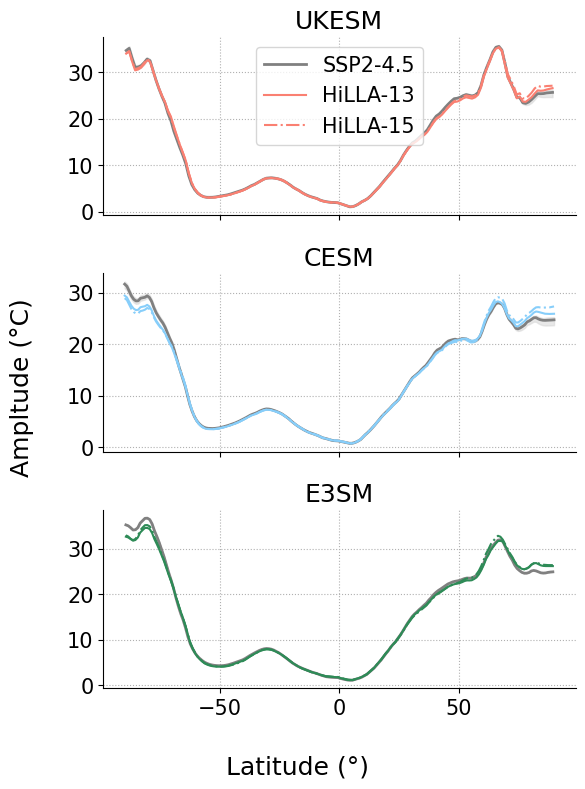

In [7]:
fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

model = 'CESM'
lss = {'13km':'solid', '15km':'dashdot'}

i=0
for model in models:
    ax = axs[i]
    # plot ssp245
    ds = SSP245_data[model]
    seasonal_climatology = ds['tas'].groupby('time.month').mean(dim='time')
    zonal_mean_seasonal_climatology = seasonal_climatology.mean(dim='longitude')
    amplitude = zonal_mean_seasonal_climatology.max(dim='month') - zonal_mean_seasonal_climatology.min(dim='month')
    ensemble_mean_amplitude = amplitude.mean(dim='Ensemble_member')
    ensemble_min_amplitude = amplitude.min(dim='Ensemble_member')
    ensemble_max_amplitude = amplitude.max(dim='Ensemble_member')
    
    ax.fill_between(amplitude.latitude, ensemble_min_amplitude, ensemble_max_amplitude, color=colours['ssp245_light'], alpha=0.5)
    ax.plot(amplitude.latitude, ensemble_mean_amplitude, color=colours['ssp245'], linewidth=2, label='SSP2-4.5')
    
    # also plot hilla
    for alt in ['13km', '15km']:
        ds = HiLLA_data[model][alt]
        seasonal_climatology = ds['tas'].groupby('time.month').mean(dim='time')
        zonal_mean_seasonal_climatology = seasonal_climatology.mean(dim='longitude')
        amplitude = zonal_mean_seasonal_climatology.max(dim='month') - zonal_mean_seasonal_climatology.min(dim='month')
        ax.plot(amplitude.latitude, amplitude, color=model_colors[model], linestyle=lss[alt], label='HiLLA-{}'.format(alt[0:2]))
            
    ax.set_title(model)
    ax.grid(ls='dotted')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    i=i+1

axs[0].legend()

fig.supxlabel('Latitude (°)')
fig.supylabel('Ampltude (°C)')
plt.tight_layout()


plt.show()

In [61]:
### also get a recent baseline:
DS_hist_tas_UK = get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'CMIP',
                              scenario = 'historical', variable='tas', members=ens_mems_arise_UK, 
                              table='Amon', grid='gn').sel(time=slice('1995', '2015')).rename({'y':'latitude', 'x':'longitude'})


DS_hist_tas_CE = get_ds_from_ceda(model='CESM2-WACCM', centre='NCAR', scenario_group = 'CMIP',
                              scenario = 'historical', variable='tas', members=['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1'], 
                              table='Amon', grid='gn').sel(time=slice('1995', '2015')).rename({'y':'latitude', 'x':'longitude'})


hist_data = {'UKESM':DS_hist_tas_UK.load(), 'CESM':DS_hist_tas_CE.load()}

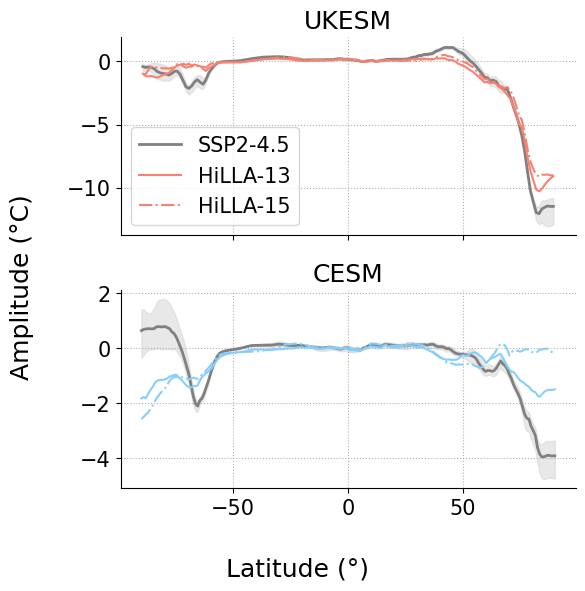

In [62]:
fig, axs = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

lss = {'13km':'solid', '15km':'dashdot'}

i=0
for model in ['UKESM', 'CESM']:
    ax = axs[i]
    base = hist_data[model]['tas'].groupby('time.month').mean(dim='time').mean(dim='longitude')
    base_amp = base.max(dim='month') - base.min(dim='month')
    # plot ssp245
    ds = SSP245_data[model].sel(time=slice('2050', '2069'))
    seasonal_climatology = ds['tas'].groupby('time.month').mean(dim='time')
    zonal_mean_seasonal_climatology = seasonal_climatology.mean(dim='longitude')
    amplitude = zonal_mean_seasonal_climatology.max(dim='month') - zonal_mean_seasonal_climatology.min(dim='month')
    ensemble_mean_amplitude = amplitude.mean(dim='Ensemble_member') - base_amp.mean('Ensemble_member')
    ensemble_min_amplitude = amplitude.min(dim='Ensemble_member') - base_amp.mean('Ensemble_member')
    ensemble_max_amplitude = amplitude.max(dim='Ensemble_member') - base_amp.mean('Ensemble_member')
    
    ax.fill_between(amplitude.latitude, ensemble_min_amplitude, ensemble_max_amplitude, color=colours['ssp245_light'], alpha=0.5)
    ax.plot(amplitude.latitude, ensemble_mean_amplitude, color=colours['ssp245'], linewidth=2, label='SSP2-4.5')
    
    # also plot hilla
    for alt in ['13km', '15km']:
        ds = HiLLA_data[model][alt].sel(time=slice('2050', '2069'))
        seasonal_climatology = ds['tas'].groupby('time.month').mean(dim='time')
        zonal_mean_seasonal_climatology = seasonal_climatology.mean(dim='longitude')
        amplitude = zonal_mean_seasonal_climatology.max(dim='month') - zonal_mean_seasonal_climatology.min(dim='month')
        ax.plot(amplitude.latitude, amplitude - base_amp.mean('Ensemble_member'), color=model_colors[model], linestyle=lss[alt], label='HiLLA-{}'.format(alt[0:2]))
            
    ax.set_title(model)
    ax.grid(ls='dotted')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    i=i+1

axs[0].legend()

fig.supxlabel('Latitude (°)')
fig.supylabel('Amplitude (°C)')
plt.tight_layout()

plt.savefig('Figures/Seasonality_changes.jpg', dpi=300)
plt.show()

In [38]:
### next, plot interhemispheric temp. difference 

def IHTD(ds):
    IHTD = spatial_mean(ds, 'NH') - spatial_mean(ds, 'SH')
    annual_max = IHTD.groupby(IHTD.time.dt.year).max()
    annual_min = IHTD.groupby(IHTD.time.dt.year).min()
    annual_mean = IHTD.groupby(IHTD.time.dt.year).mean()
    return {'monthly_ts':IHTD, 
            'annual_mean':annual_mean, 
            'annual_max':annual_max, 
            'annual_min':annual_min,
            'annual_amp':annual_max - annual_min}


In [39]:
IHTD_dict = IHTD(ds_HiLLA_13_CE.tas)

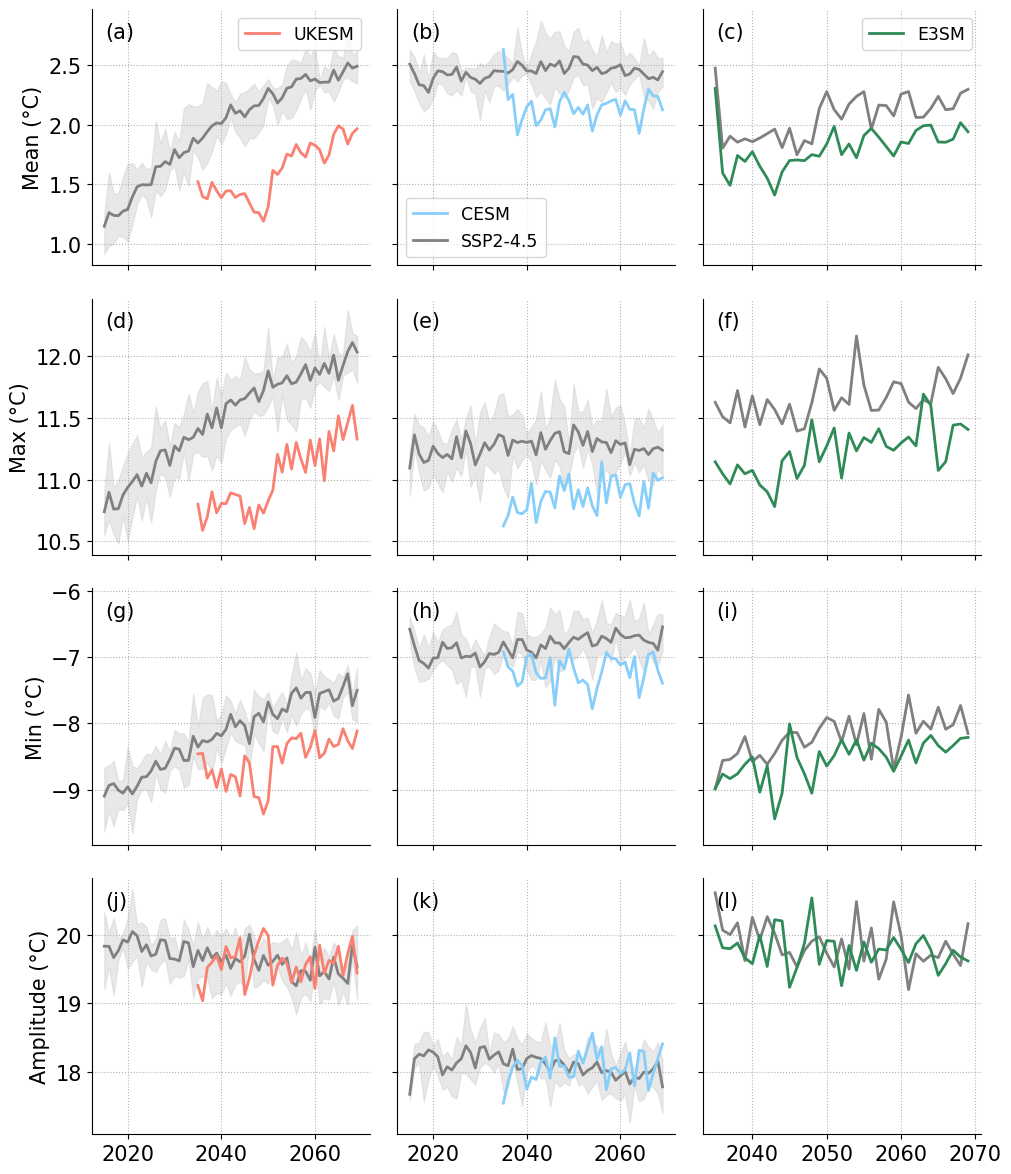

In [68]:
fig, axs = plt.subplots(4, 3, figsize=(10, 12), sharex='col', sharey='row')

#lss = {'13km':'solid', '15km':'dashdot'}
ylabs = ['Mean (°C)', 'Max (°C)', 'Min (°C)', 'Amplitude (°C)']
titles = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)", "(i)", "(j)", "(k)", "(l)"]
i=0
for model in models:
    l=0
    for val in ['annual_mean', 'annual_max', 'annual_min', 'annual_amp']:
        ax = axs[l, i]
        IHTD_dict_ssp = IHTD(SSP245_data[model].tas)
        IHTD_to_plot = IHTD_dict_ssp[val]
        ax.fill_between(IHTD_to_plot.year, IHTD_to_plot.min('Ensemble_member'), IHTD_to_plot.max('Ensemble_member'), color=colours['ssp245_light'], alpha=0.5)
        ax.plot(IHTD_to_plot.year, IHTD_to_plot.mean('Ensemble_member'), color=colours['ssp245'], linewidth=2)                     
        
        #for alt in ['13km', '15km']:
        IHTD_dict_HiLLA = IHTD(HiLLA_data[model][alt].tas)
        IHTD_to_plot = IHTD_dict_HiLLA[val]
        ax.plot(IHTD_to_plot.year, IHTD_to_plot, linewidth=2, color=model_colors[model], label='{}'.format(model))
        ax.grid(ls='dotted')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        if i == 1:
            ax.plot([], [], color=colours['ssp245'], linewidth=2, label='SSP2-4.5')
        if i == 0:
            ax.set_ylabel(ylabs[l])
        if l == 0:
            ax.legend(fontsize='small')
        l=l+1
    i=i+1

k=0
for ax in axs.flatten():
    ax.text(x=0.05,y=0.95,s=titles[k],transform=ax.transAxes,ha='left',va='top',fontsize='medium')
    k=k+1

plt.tight_layout()
plt.savefig('Figures/IHTD_seasonal_cycle.jpg', dpi=350)